In [1]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

In [2]:
dataset = load_breast_cancer() # loading breast cancer dataset from scikit-learn
print(dataset.keys()) # list the contents of the dataset
print(dataset.data.shape) # shape of the X matrix

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(569, 30)


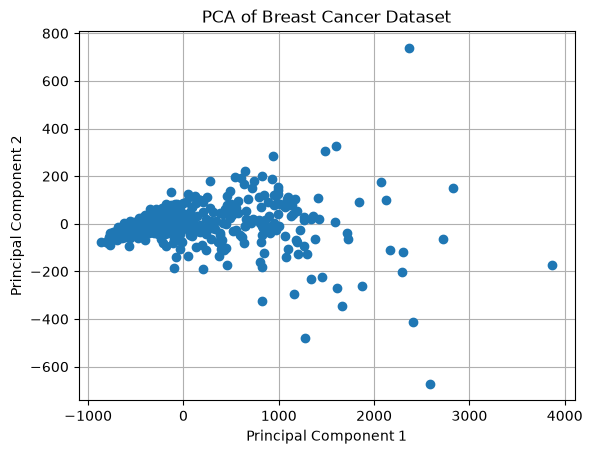

In [3]:
# Task 1: Applying principal component analysis (PCA) to data set & visualizing

# defining PCA with 2 components and fitting PCA to the data and transforming it
transformed_data = (PCA(n_components=2).fit_transform(dataset.data)) 

#print(pca.shape) # checking the shape

# Creating a scatterplot to visualize the transformed data
plt.plot(transformed_data[:, 0], transformed_data[:, 1], 'o')  # plotting data points
plt.xlabel("Principal Component 1") # defining x axis label on plot
plt.ylabel("Principal Component 2") # defining y axis label on plot
plt.title("PCA of Breast Cancer Dataset") # plot title
plt.grid(True) # adding a grid for better visibility
plt.show()

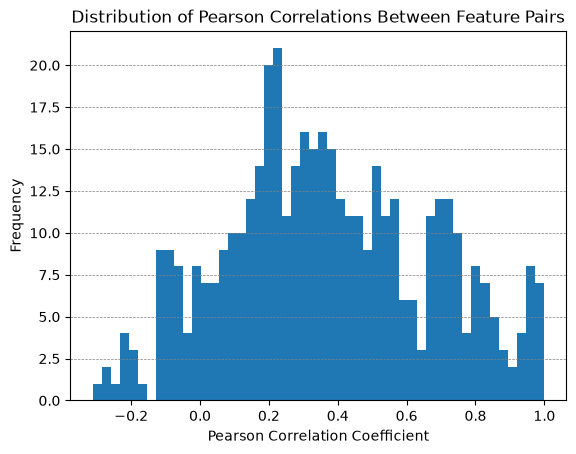

In [4]:
# Task 2: Determining correlation using Pearson Correlation Coefficient

# Calculating the symmetric correlation matrix
correlation_matrix = np.corrcoef(dataset.data, rowvar=False)

# print(correlation_matrix.shape) # checking for 30x30 shape

# zeroing out redundant values (i.e. self-correlation, duplicate correlations)
valid_correlations = np.tril(correlation_matrix, k=-1)

# converting 2D array to a 1D array
flatt_array = valid_correlations.flatten()

# removing the zeroed out redundancies
flatt_array = flatt_array[flatt_array != 0]

# histogram plot
plt.hist(flatt_array, bins=50) # defining histogram plot type and 50 bins
plt.xlabel("Pearson Correlation Coefficient") # plot x axis label
plt.ylabel("Frequency") # plot y axis label
plt.title("Distribution of Pearson Correlations Between Feature Pairs") # plot title
plt.grid(True, axis='y', color='gray', linestyle='--', linewidth=0.5) # adding horizontal gridlines for better visibility
plt.show()

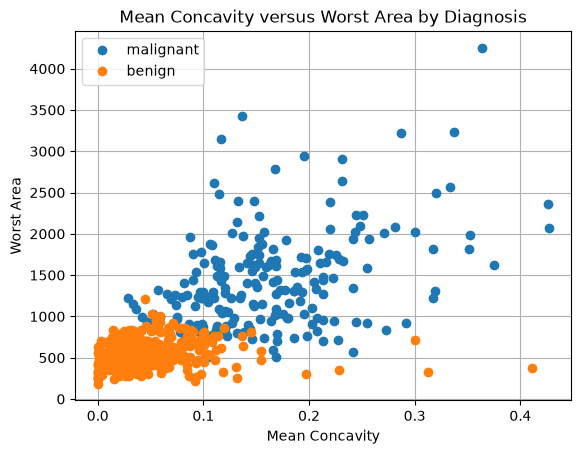

In [5]:
# Task 3: Plotting Mean concavity vs worst area, coloured by class label (malignant vs. benign)

# searching column indices for the features: mean concavity & worst area
feature_names = list(dataset.feature_names)
mean_concavity = feature_names.index('mean concavity') # assigning the feature 'mean area' to a variable
worst_area = feature_names.index('worst area') # assigning the feature 'worst concavity' to a variable

# defining malignant and benign data points (aka class label)
target = dataset.target
malignant = dataset.data[target == 0]  # assigning the target 0 to variable 'malignant'
benign = dataset.data[target == 1]  # assigning the target 1 to variable 'benign'

# Plotting each class separately so they get different colors and a legend
plt.plot(malignant[:, mean_concavity], malignant[:, worst_area], 'o', label=dataset.target_names[0])
plt.plot(benign[:, mean_concavity], benign[:, worst_area], 'o', label=dataset.target_names[1])

plt.xlabel("Mean Concavity") # plot x axis label
plt.ylabel("Worst Area") # plot y axis label
plt.title("Mean Concavity versus Worst Area by Diagnosis")  # plot title
plt.legend() # plot legend
plt.grid(True) # adding a grid for visibility
plt.show()

The feature with the highest mean is worst area at index 23 with a mean of 880.5831282952545
The feature with the highest median is worst area at index 23 with a median of 686.5
The feature with the highest variance is worst area at index 23 with a variance of 568.8564589532672


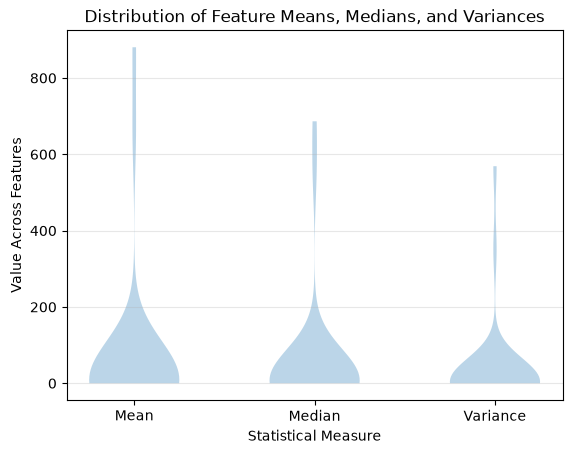

In [6]:
# Task 4: Representing features with the highest mean, median, & variance.

# Finding the feature with the maximum mean
all_mean = np.mean(dataset.data, axis = 0) # calculating the means of all features in the dataset
max_mean = np.max(all_mean) # finding the highest mean
max_mean_index = np.argmax(all_mean) # determining which feature index hosts the highest mean

print("The feature with the highest mean is", dataset.feature_names[max_mean_index], "at index", max_mean_index, "with a mean of", max_mean) # printing the feature with the highest mean, its index, and its mean.

# Finding the feature with the maximum median
all_med = np.median(dataset.data, axis = 0) # calculating the median of all features in the dataset
max_med = np.max(all_med) # finding the highest median
max_med_index = np.argmax(all_med) # determining which feature index hosts the highest median

print("The feature with the highest median is", dataset.feature_names[max_med_index], "at index",  max_med_index, "with a median of", max_med) # printing the feature with the highest median, its index, and its median.

# Finding the feature with the highest variance
# Note: the assignment asks to find the variance, but the suggested method was np.std (which finds the standard deviation), since both values can be derived from one another, I will use the suggested method for standard deviation and refer to it as variance 
all_var = np.std(dataset.data, axis =0) # calculating the standard deviation of all features in the dataset 
max_var = np.max(all_var) # finding the highest variance
max_var_index = np.argmax(all_var) # determining which feature index  hosts the highest variance

print("The feature with the highest variance is", dataset.feature_names[max_var_index],"at index", max_var_index, "with a variance of", max_var) # printing the feature with the highest variance*, its index, and its variance*.

# Creating a violinplot of the vertical distributions of the mean, median, and variance of the features:
plt.violinplot([all_mean, all_med, all_var ], showextrema=False) 
plt.grid(True, axis='y', alpha=0.3) # adding a grid for visibility
plt.title("Distribution of Feature Means, Medians, and Variances") # plot title
plt.xlabel("Statistical Measure") # plot x axis label
plt.ylabel("Value Across Features") # plot y axis label
plt.xticks([1, 2, 3], ["Mean", "Median", "Variance"]) # adding labels to each violinplot
plt.show()
# Note: Due to the spread of the data I would add a log scale to show the spread but since the assignment does not ask for that I chose not to do so

In [7]:
# Task 5: Dividing data into training and test set

# importing modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# splitting the data into training and testing set
train_features, test_features, train_values, test_values = train_test_split(dataset.data, dataset.target, test_size=0.2, shuffle=False)

#print(train_features.shape) # checking the shape of training features
#print(test_features.shape) # checking the shape of testing features

# Training a logistic regression classifier on the training split
target_model = LogisticRegression(max_iter=int(1e4))
target_model.fit(train_features, train_values)

# scoring on the test split to determine the out-of-sample classification accuracy
score = target_model.score(test_features, test_values)
print("The model's out-of-sample classification accuracy is:", score*100, "%") # printing the score of model's performance on the test split

print("The number of iterations it took for the model to converge:", target_model.n_iter_) # checking how many iterations it took for the model to converge

The model's out-of-sample classification accuracy is: 93.85964912280701 %
The number of iterations it took for the model to converge: [2484]


In [8]:
# Task 6: pipeline model combining standardization and logistic regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# creating a pipeline that standardizes the data before classifying it using the logistic regression model in the previous task
pipeline_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=int(1e4)))

# Training the pipeline model on the same training split used in the previous task
pipeline_model.fit(train_features, train_values)

# Scoring the pipeline model on the test split to determine the out-of-sample classification accuracy and compare it to the previous task
pipeline_score = pipeline_model.score(test_features, test_values)
print("The model's out-of-sample classification accuracy is:", pipeline_score*100, "%")

# Checking impact of scaling on the # of iterations it took the model to converge
print("The number of iterations it took for the model to converge is:", pipeline_model.named_steps['logisticregression'].n_iter_) # note: logisticregression attribute alone was not recognize so used named_steps

The model's out-of-sample classification accuracy is: 98.24561403508771 %
The number of iterations it took for the model to converge is: [18]


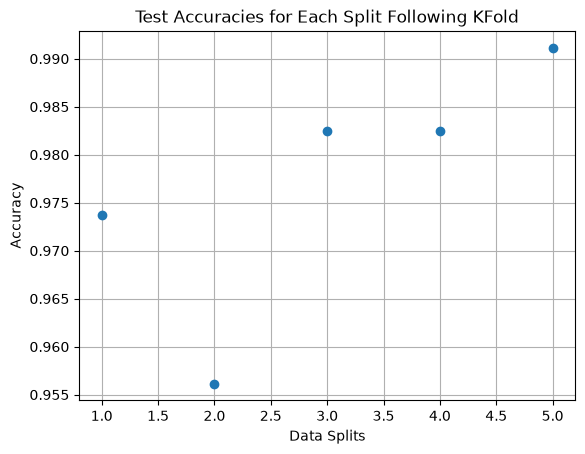

In [9]:
# Task 7: pipeline model training 
from sklearn.model_selection import KFold

# dividing the data into training and test sets using kfold
kfold_split_fn = KFold(n_splits=5, shuffle=False)
kfold_split = kfold_split_fn.split(dataset.data)

split_score = [] # creating a list to append test accuracies

# training a pipeline model (new model with the same configuration as Task 6) on each of the 5 K-fold splits
for kftrain_index, kftest_index in kfold_split:
    feature_train_fold = dataset.data[kftrain_index]
    feature_test_fold = dataset.data[kftest_index]
    value_train_fold = dataset.target[kftrain_index]
    value_test_fold = dataset.target[kftest_index]
    kfold_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))
    kfold_model.fit(feature_train_fold, value_train_fold)
    split_score.append(kfold_model.score(feature_test_fold,value_test_fold))

# creating a scatterplot of the test accuracies for each split
plt.plot([1, 2, 3, 4, 5], split_score, 'o')

plt.xlabel("Data Splits") # x axis label
plt.ylabel("Accuracy") # y axis label
plt.title("Test Accuracies for Each Split Following KFold") # plot title
plt.grid(True) # including a grid for visibility
plt.show()


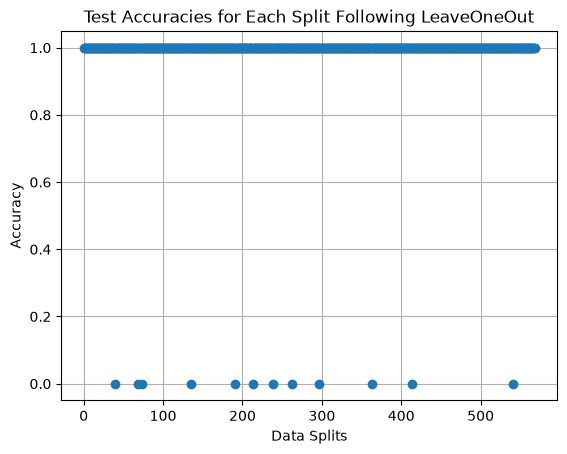

In [10]:
# Task 8: Scatterplot of test accuracies for each split using LeaveOneOut
from sklearn.model_selection import LeaveOneOut

# dividing the data into training and test sets
leave_split = LeaveOneOut()
leave_split_fn = leave_split.split(dataset.data)

leave_score = [] # creating a list to append test accuracies

# training a pipeline model (new model with the same configuration as Task 6) on each split
for leave_train_index, leave_test_index in leave_split_fn:
    feature_train_leave = dataset.data[leave_train_index]
    feature_test_leave = dataset.data[leave_test_index]
    value_train_leave = dataset.target[leave_train_index]
    value_test_leave = dataset.target[leave_test_index]
    leave_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))
    leave_model.fit(feature_train_leave, value_train_leave)
    leave_score.append(leave_model.score(feature_test_leave,value_test_leave))

#print(leave_score) # printing the score

# creating a scatterplot of the test accuracies for each split
plt.plot(range(len(leave_score)), leave_score, 'o')

plt.xlabel("Data Splits") # x axis label
plt.ylabel("Accuracy") # y axis label
plt.title("Test Accuracies for Each Split Following LeaveOneOut") # plot title
plt.grid(True) # adding grid for visibility
plt.show()